## 1. Importing the neccesary libraries

In [36]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")


## 2. Loading and Exploring Data (EDA)

In [37]:

import arff
import pandas as pd


with open(r"C:\Users\User\Downloads\dataset.arff") as f:
    dataset = arff.load(f)

df = pd.DataFrame(
    dataset['data'],
    columns=[attr[0] for attr in dataset['attributes']]
)

df.head()


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [38]:

df.info()
df.isnull().sum().sort_values(ascending=False) # Checking for missingness


<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 57.8 MB


CO         20701
O3         13277
NO2        12116
SO2         9021
PM2.5       8739
PM10        6449
wd          1822
DEWP         403
TEMP         398
PRES         393
RAIN         390
WSPM         318
year           0
No             0
day            0
month          0
hour           0
station        0
dtype: int64

In [39]:
# Setting the date as the index
df['datetime'] = pd.to_datetime(
    df[['year','month','day','hour']]
)

df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

df.head()


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,,
2013-03-01,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
2013-03-01,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
2013-03-01,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
2013-03-01,1,2013,3,1,0,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu
2013-03-01,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping


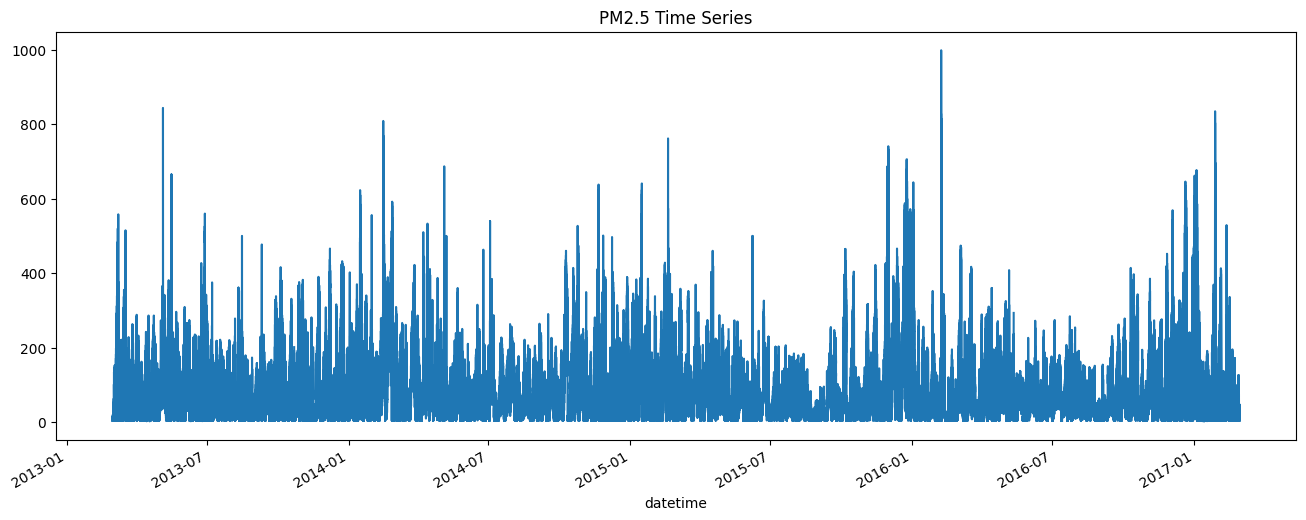

In [40]:
# Plot the PM2.5 time series to visually inspect its behavior over time.
# This helps identify trends, seasonality, and changes in variance, which are indicators of non-stationarity.
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(16,6))
df['PM2.5'].plot()
plt.title("PM2.5 Time Series")
plt.show()


Based on the time-series plot, the PM2.5 data exhibits non-stationary behavior characterized by strong annual seasonality and highly volatile, time-dependent variance. While the baseline of the data remains relatively flat near zero from 2013 through 2017 without a clear long-term upward or downward linear trend, the data cannot be considered stationary because its statistical properties change over time. Specifically, there is a recurring cyclical pattern where extreme pollution spikes consistently cluster around the beginning and end of each year (winter months), contrasted by periods of low, stable activity during the middle of each year (summer months). This fluctuating variance across different seasons, combined with prominent anomalies like the massive spike in early 2016 and a prolonged period of low activity in late 2015, confirms that the series requires transformation before it can be used for standard statistical modeling.

## 3. Missing Value Treatment

In [41]:

missing_percent = (df.isnull().sum()/len(df))*100
missing_percent.sort_values(ascending=False)


CO         4.919813
O3         3.155421
NO2        2.879497
SO2        2.143937
PM2.5      2.076916
PM10       1.532674
wd         0.433018
DEWP       0.095777
TEMP       0.094589
PRES       0.093401
RAIN       0.092688
WSPM       0.075576
year       0.000000
No         0.000000
day        0.000000
month      0.000000
hour       0.000000
station    0.000000
dtype: float64

In [42]:
# Interpolate missing values in all numeric columns using the time index.
# This estimates missing observations based on the values before and after them, preserving the temporal pattern of the time series.
df[numeric_cols] = df[numeric_cols].interpolate(method='time')

# Fill any remaining missing values.
# Forward fill (ffill) propagates the previous valid observation forward, while backward fill (bfill) propagates the next valid observation backward.
# This ensures that no missing values remain in the numeric features.
df[numeric_cols] = df[numeric_cols].ffill().bfill()

# Verify that all missing values have been handled.
# The result should be 0 if the dataset contains no null values.
df.isnull().sum().sum()


np.int64(1822)

## 4. Exploratory Data Analysis

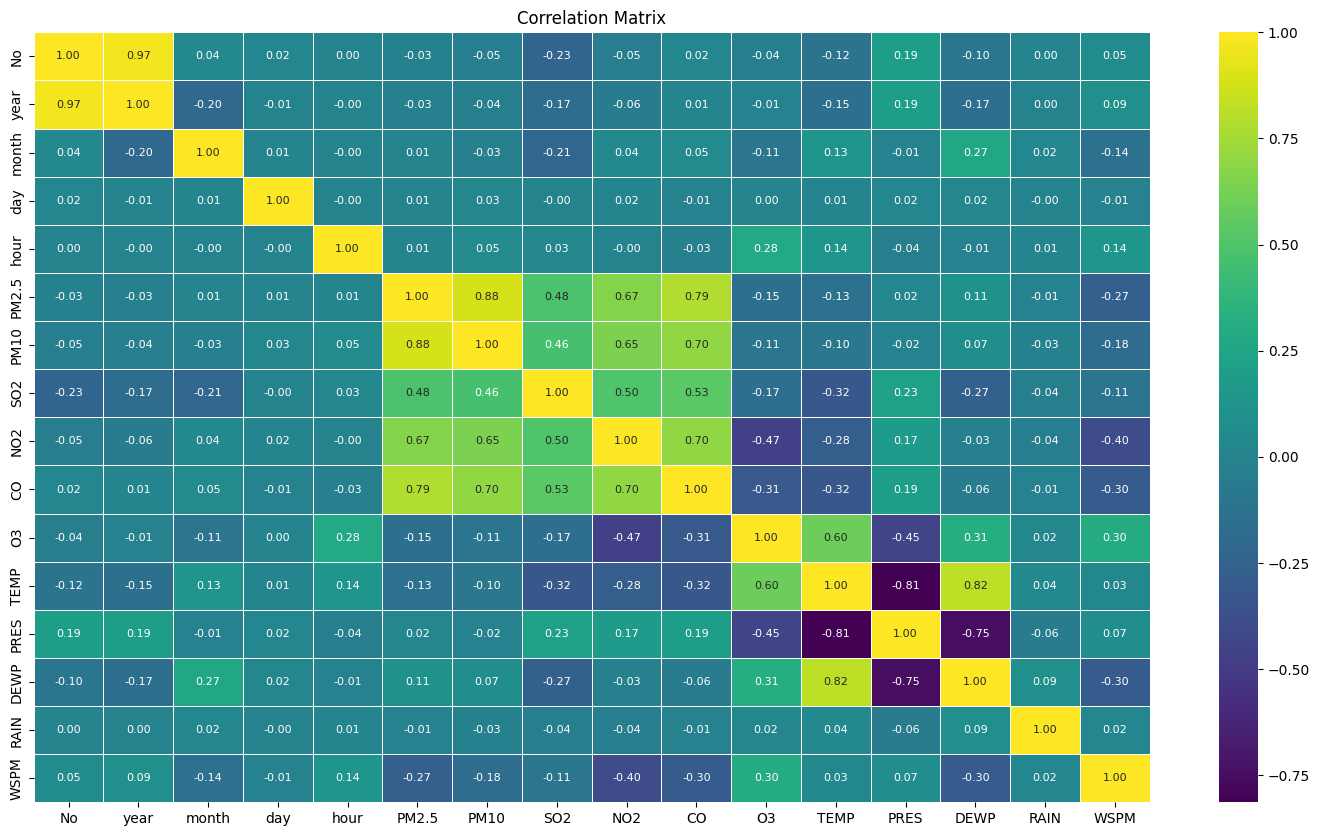

In [43]:

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(18,10))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation values
    fmt=".2f",           # Display 2 decimal places
    cmap="viridis",
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix")
plt.show()


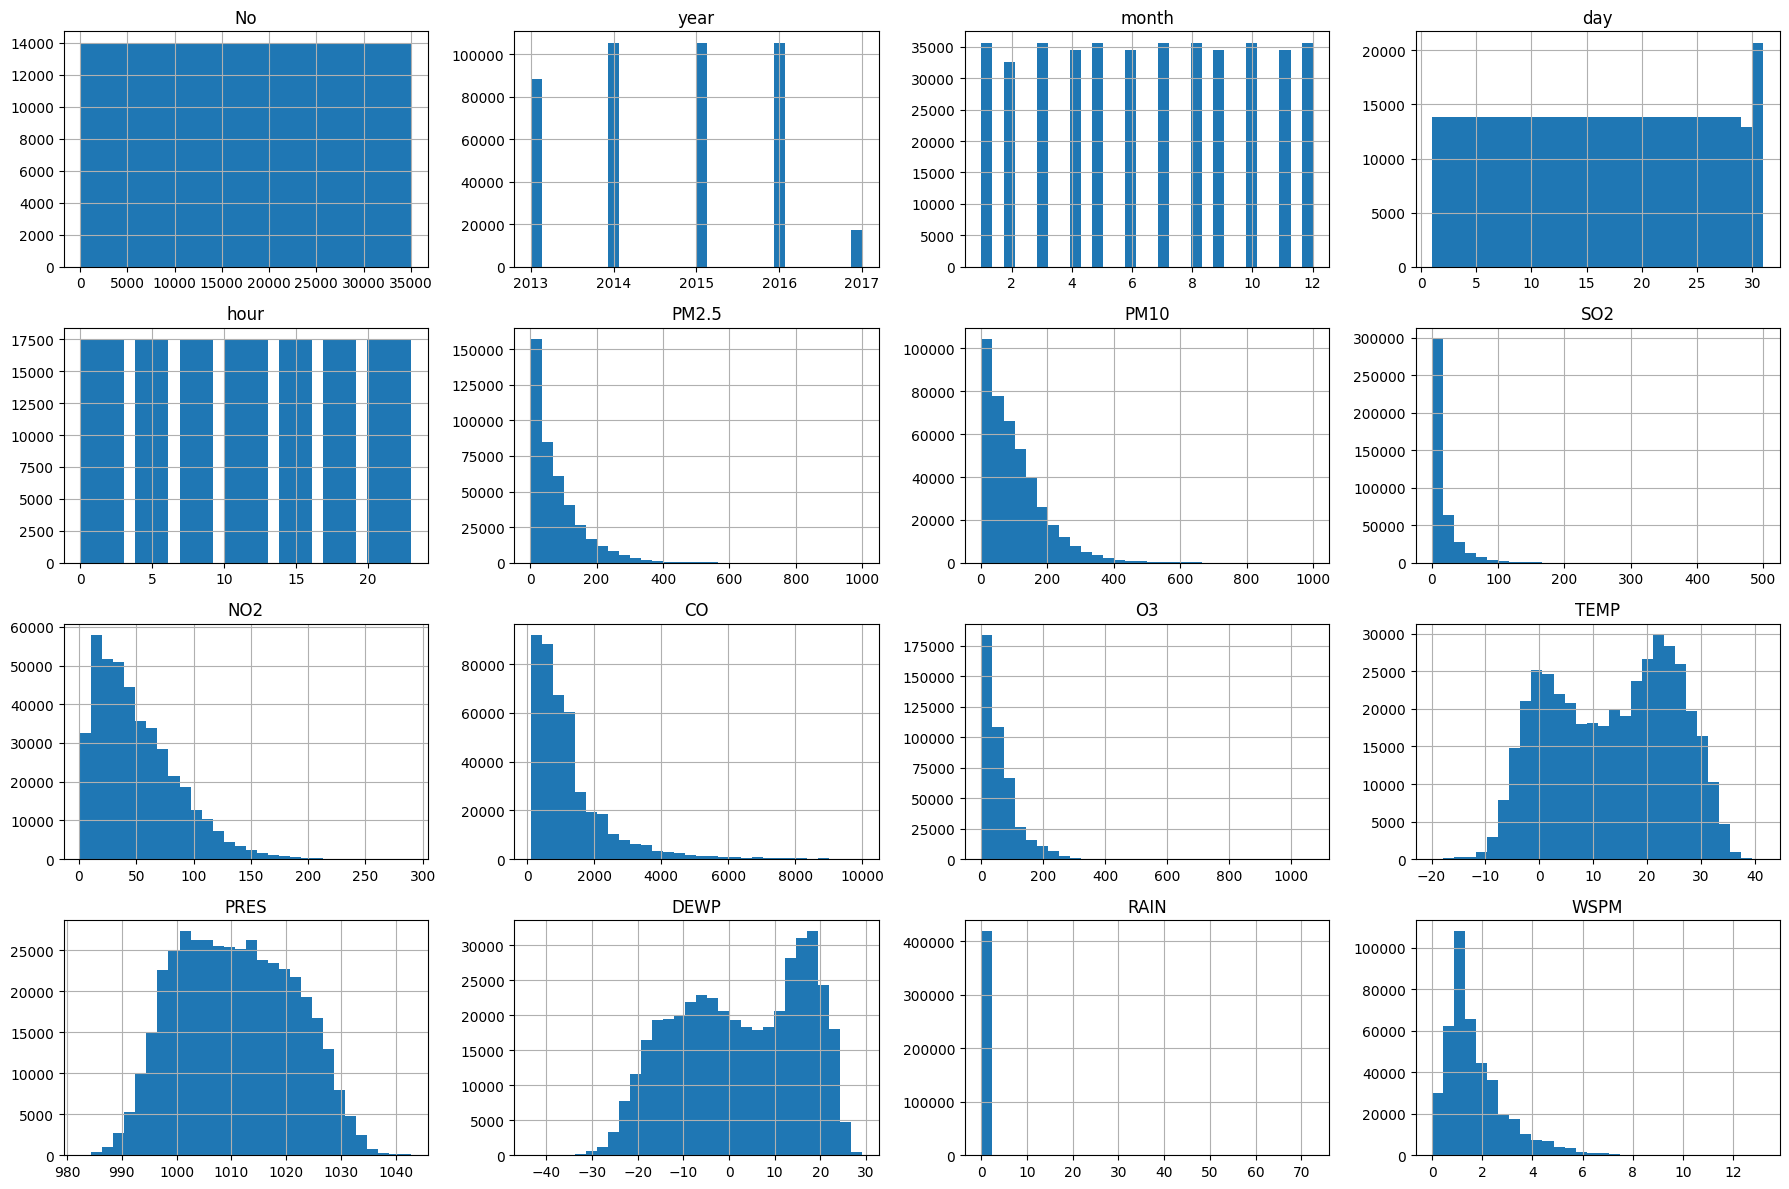

In [44]:

# Plot histograms for all numeric features in the dataset.
# Histograms help visualize the distribution of each variable,
# including its central tendency, spread, skewness, and potential outliers.

df[numeric_cols].hist(
    figsize=(18,12),
    bins=30
)

# Adjust subplot spacing to prevent overlapping labels and titles.
plt.tight_layout()

# Display the histograms.
plt.show()



## 5. Time Series Decomposition

inspecting trend, seasonality and residuals.


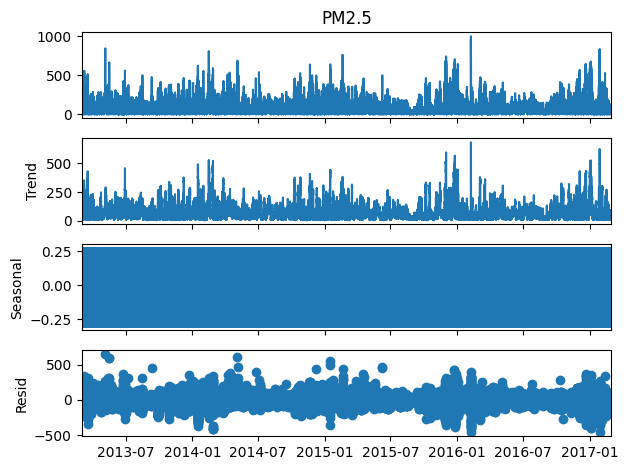

In [45]:

# Define the target variable for forecasting.
# PM2.5 represents the concentration of fine particulate matter in the air.
target = 'PM2.5'

# Decompose the PM2.5 time series into its underlying components:
# - Trend: long-term movement in PM2.5 levels
# - Seasonal: repeating patterns occurring at regular intervals
# - Residual: random fluctuations not explained by trend or seasonality

# period=24 is used because the dataset contains hourly observations,
# and one complete seasonal cycle is assumed to occur every 24 hours.
result = seasonal_decompose(
    df[target],
    model='additive',
    period=24
)

# Plot the decomposed components of the time series.

result.plot()

# Display the decomposition plots.
plt.show()


## 6. Stationarity Testing

In [46]:
print(df[target].dtype)
print(df[target].shape)
print(len(df))

float64
(420768,)
420768


In [47]:
# Remove any missing values from the target variable (PM2.5)
# and select the first 50,000 observations for the stationarity test.
sample = df[target].dropna().iloc[:50000]

# Perform the Augmented Dickey-Fuller (ADF) test.
# The ADF test checks whether the time series is stationary.

result = adfuller(sample)

# Display the ADF test statistic.
# More negative values provide stronger evidence against the null hypothesis.
print("ADF Statistic:", result[0])

# Display the p-value.
# If p-value < 0.05, we reject the null hypothesis
# and conclude that the series is stationary.
print("p-value:", result[1])

ADF Statistic: -9.852433197276644
p-value: 4.4489906872671943e-17


p-value < 0.05  -> Time series is stationary.

 p-value >= 0.05 -> Time series is non-stationary and may require differencing.

In [48]:
# Aggregate First Since I have 420k hourly observations resampling is better

daily_pm25 = df[target].resample('D').mean()

In [49]:
result = adfuller(daily_pm25.dropna())

# Reduces noise Makes seasonality easier to see Speeds up ARIMA/SARIMA considerably

In [50]:
print(df.shape)

print(
    df.index.nunique(),
    len(df)
)

print(df.index.min())
print(df.index.max())

(420768, 18)
35064 420768
2013-03-01 00:00:00
2017-02-28 23:00:00


Since the data appears to contain 12 stations for every timestamp,create a city-wide average PM2.5 series first to reduces the dataset from 420,768 rows to about 35,064 rows, making ADF, ARIMA, and SARIMA much faster.

In [51]:
# Create City-Wide PM2.5 Series
# Average PM2.5 across all stations for each timestamp

city_pm25 = df.groupby(df.index)['PM2.5'].mean()

print(city_pm25.shape)
city_pm25.head()

(35064,)


datetime
2013-03-01 00:00:00    5.666667
2013-03-01 01:00:00    6.833333
2013-03-01 02:00:00    5.666667
2013-03-01 03:00:00    6.000000
2013-03-01 04:00:00    4.833333
Name: PM2.5, dtype: float64

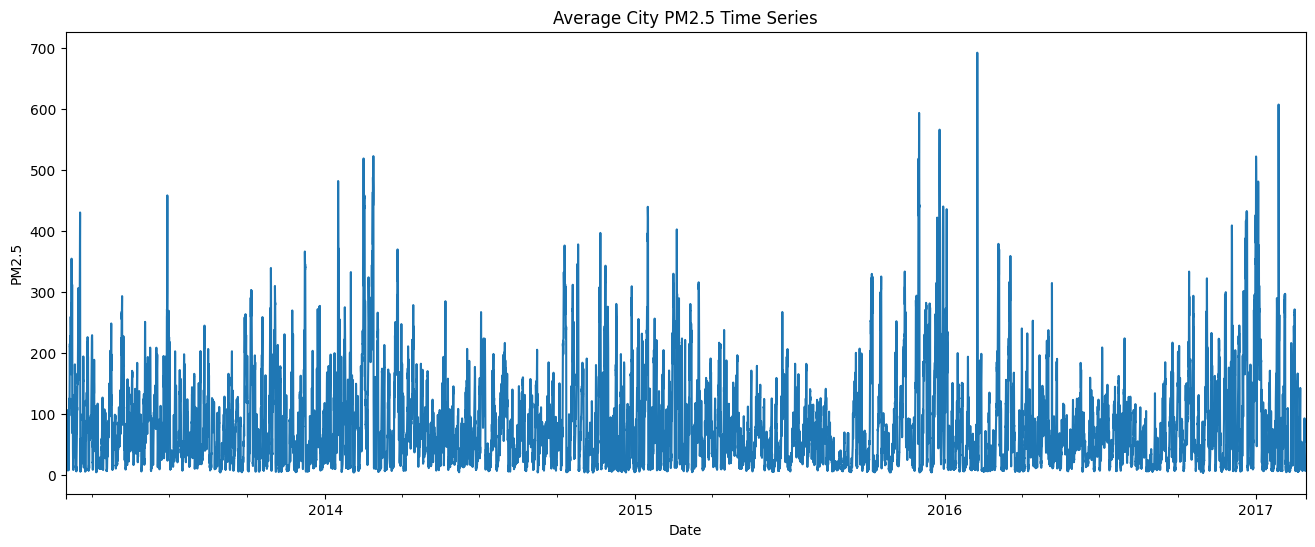

In [52]:
# Visualize the Time Series
plt.figure(figsize=(16,6))

city_pm25.plot()

plt.title('Average City PM2.5 Time Series')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.show()

In [53]:
# Check Stationarity (ADF Test)
from statsmodels.tsa.stattools import adfuller

def adf_test(series):

    result = adfuller(
        series.dropna(),
        maxlag=24,
        autolag='AIC'
    )

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value}")

    if result[1] < 0.05:
        print("\nSeries is Stationary")
    else:
        print("\nSeries is Non-Stationary")

adf_test(city_pm25)

ADF Statistic: -22.588838577158022
p-value: 0.0

Critical Values:
1%: -3.4305366428588395
5%: -2.8616224915342734
10%: -2.5668139076505554

Series is Stationary


In [54]:
# Difference if Necessary
city_pm25_diff = city_pm25.diff()

adf_test(city_pm25_diff.dropna())

ADF Statistic: -41.78973700506499
p-value: 0.0

Critical Values:
1%: -3.4305366375318838
5%: -2.861622489179964
10%: -2.566813906397418

Series is Stationary


## 7. ACF and PACF Analysis

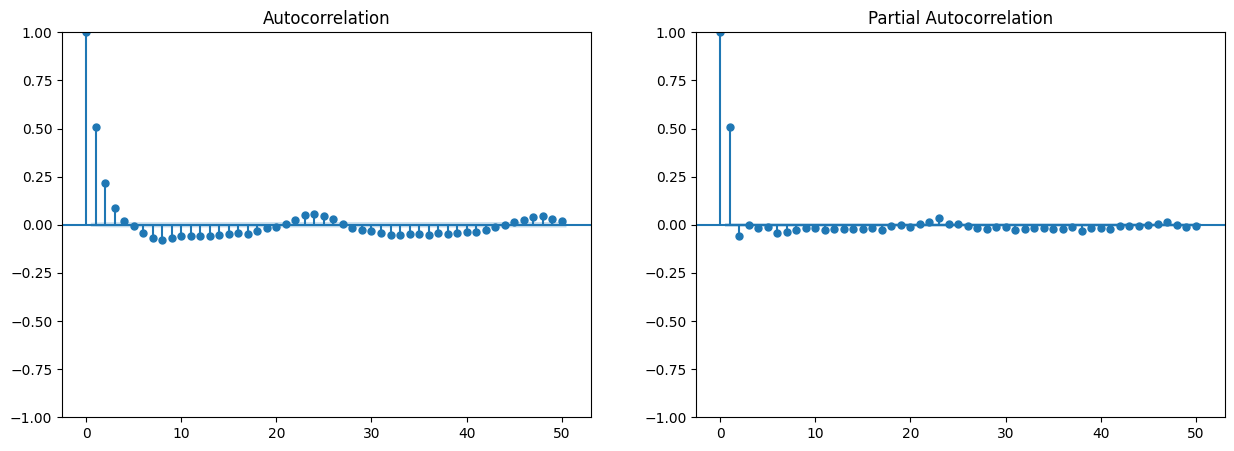

In [55]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2, figsize=(15,5))

plot_acf(city_pm25_diff.dropna(), lags=50, ax=ax[0])
plot_pacf(city_pm25_diff.dropna(), lags=50, ax=ax[1])

plt.show()

#### Insights from ACF/PACF plots
The ACF and PACF plots suggest an Autoregressive (AR) pattern in the PM2.5 data. The PACF shows a strong spike at lag 1, while the ACF decreases gradually, indicating that an AR(1) model may be suitable.

The ACF also shows peaks at lags 24 and 48, revealing a 24-hour seasonal pattern. Therefore, a SARIMA model with a seasonal period of 24 is appropriate for capturing both short-term and daily variations in PM2.5 levels.


## 8. Feature Engineering

In [56]:
# Lag Features
for lag in [1, 3, 6, 12, 24]:
    df[f'lag_{lag}'] = df['PM2.5'].shift(lag)

# Rolling Features
df['rolling_mean_24'] = df['PM2.5'].rolling(24).mean()
df['rolling_std_24'] = df['PM2.5'].rolling(24).std()

# Time Features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

df.dropna(inplace=True)

## 9. Train-Test Split

In [57]:
series = city_pm25

split = int(len(series) * 0.8)

train = series[:split]
test = series[split:]

print(train.shape)
print(test.shape)

(28051,)
(7013,)


## 10. ARIMA Model

In [58]:

# This models hour-to-hour relationships 
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test))

## 11. SARIMA Model

In [59]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Order=(1,1,1) handles short-term hourly dependencies
# seasonal_order=(1,0,0,24) handles the recurring 24-hour daily cycle
sarima_model = SARIMAX(
    train, 
    order=(1, 1, 1), 
    seasonal_order=(1, 0, 0, 24)
)

# Fit the model
sarima_fit = sarima_model.fit(disp=False)

# Forecast for the test set duration
sarima_pred = sarima_fit.forecast(
    steps=len(test)
)

## 13. Evaluation Function

In [60]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate(y_true, y_pred, fitted_model, model_name):
    # Calculate sklearn metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Extract information criteria from the fitted statsmodels object
    aic = fitted_model.aic
    bic = fitted_model.bic

    print(f"\n{model_name}")
    print("-" * 30)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"AIC  : {aic:.4f}")
    print(f"BIC  : {bic:.4f}")


# Run evaluation for both models
evaluate(test, arima_pred, arima_fit, "ARIMA")
evaluate(test, sarima_pred, sarima_fit, "SARIMA")



ARIMA
------------------------------
MAE  : 67.4936
RMSE : 102.7619
R2   : -0.7314
AIC  : 213332.1928
BIC  : 213356.9181

SARIMA
------------------------------
MAE  : 69.5536
RMSE : 104.4347
R2   : -0.7882
AIC  : 213324.9936
BIC  : 213357.9606


The results show that ARIMA performed slightly better than SARIMA on the test data, with lower MAE (67.49) and RMSE (102.76) values. SARIMA had a lower AIC, indicating a better fit to the training data, but a slightly higher BIC due to its added complexity.

However, both models produced negative R² score, showing that they were unable to accurately predict PM2.5 levels.

## 14. Forecast Visualization

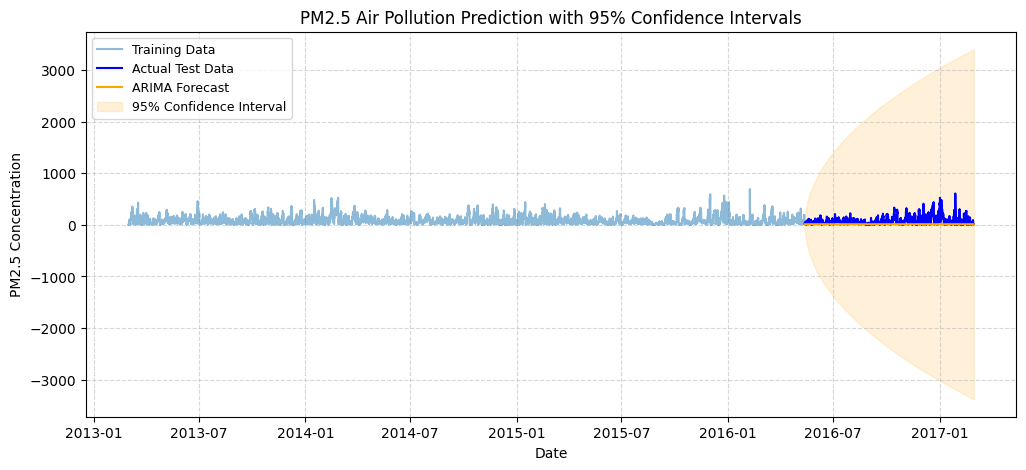

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Generate the forecast object using your fitted model (e.g., arima_fit or sarima_fit)
n_steps = len(test)
forecast_obj = arima_fit.get_forecast(steps=n_steps)

# 2. Extract predicted mean and confidence intervals
y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# 3. Convert them to series matching your test index
fc_series = pd.Series(y_pred.values, index=test.index)
lower_series = pd.Series(conf_int.iloc[:, 0].values, index=test.index)
upper_series = pd.Series(conf_int.iloc[:, 1].values, index=test.index)

# 4. Plotting the updated visualization
plt.figure(figsize=(12, 5), dpi=100)

# Note: If your training data is too long and squishes the plot,
# you can use train.tail(500) instead of the full train set.
plt.plot(train, label="Training Data", alpha=0.5)
plt.plot(test, color="blue", label="Actual Test Data")
plt.plot(fc_series, color="orange", label="ARIMA Forecast")

# Plot the 95% uncertainty band
plt.fill_between(
    lower_series.index,
    lower_series,
    upper_series,
    color="orange",
    alpha=0.15,
    label="95% Confidence Interval",
)

# Customizing titles and labels for PM2.5
plt.title("PM2.5 Air Pollution Prediction with 95% Confidence Intervals")
plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


The 95% confidence interval plot shows that forecast uncertainty increases as the prediction horizon gets longer. The confidence bands become very wide and even include negative PM2.5 values, which are not realistic.

This indicates that the ARIMA model becomes less reliable for long-term forecasting and struggles to maintain accurate predictions over extended periods.

To reduce forecast uncertainty and avoid unrealistic negative PM2.5 values, a log transformation should be applied before training the model. Using `np.log1p()` stabilizes the variance and reduces the effect of extreme spikes. After forecasting, the predictions and confidence intervals can be converted back to the original scale using `np.expm1()`.


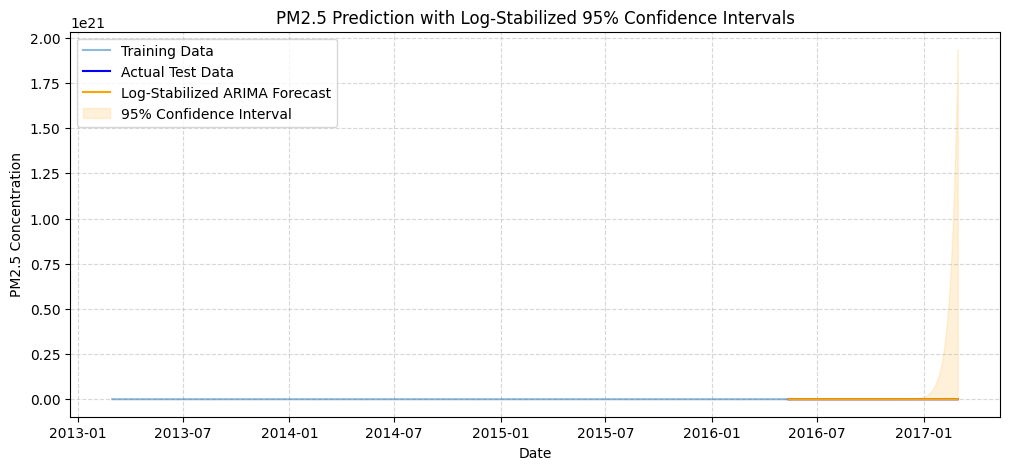

In [62]:


# Transform the data to log-scale 
train_log = np.log1p(train)
test_log = np.log1p(test)

# Fit the model on log-scale data 
arima_model = ARIMA(train_log, order=(1, 1, 1))
arima_fit = arima_model.fit()

# Generate the forecast in log-scale 
n_steps = len(test)
forecast_obj = arima_fit.get_forecast(steps=n_steps)

# Extract log-scale predicted mean and confidence intervals
y_pred_log = forecast_obj.predicted_mean
conf_int_log = forecast_obj.conf_int()

# Inverse transform everything back to original scale
# Using np.expm1 reverses the np.log1p transformation
fc_series = pd.Series(np.expm1(y_pred_log.values), index=test.index)
lower_series = pd.Series(
    np.expm1(conf_int_log.iloc[:, 0].values), index=test.index
)
upper_series = pd.Series(
    np.expm1(conf_int_log.iloc[:, 1].values), index=test.index
)

# Plot the results
plt.figure(figsize=(12, 5), dpi=100)

plt.plot(train, label="Training Data", alpha=0.5)
plt.plot(test, color="blue", label="Actual Test Data")
plt.plot(fc_series, color="orange", label="Log-Stabilized ARIMA Forecast")

# Shading the new log-bounded confidence intervals
plt.fill_between(
    lower_series.index,
    lower_series,
    upper_series,
    color="orange",
    alpha=0.15,
    label="95% Confidence Interval",
)

plt.title("PM2.5 Prediction with Log-Stabilized 95% Confidence Intervals")
plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


The log transformation removed the problem of negative confidence intervals, but it caused the upper confidence bound to become extremely large after applying the inverse transformation (np.expm1()). As the forecast horizon increased, forecast uncertainty grew rapidly, leading to an unrealistic upper bound that distorted the plot. As a result, the actual values and forecasts appeared compressed near the bottom of the graph, making them difficult to interpret.

To address this issue, the forecasts and confidence intervals can be plotted directly in log scale instead of converting them back to the original scale. This approach prevents extreme values from distorting the graph, keeps the confidence intervals well-behaved, and makes the actual data and forecasts easier to compare.

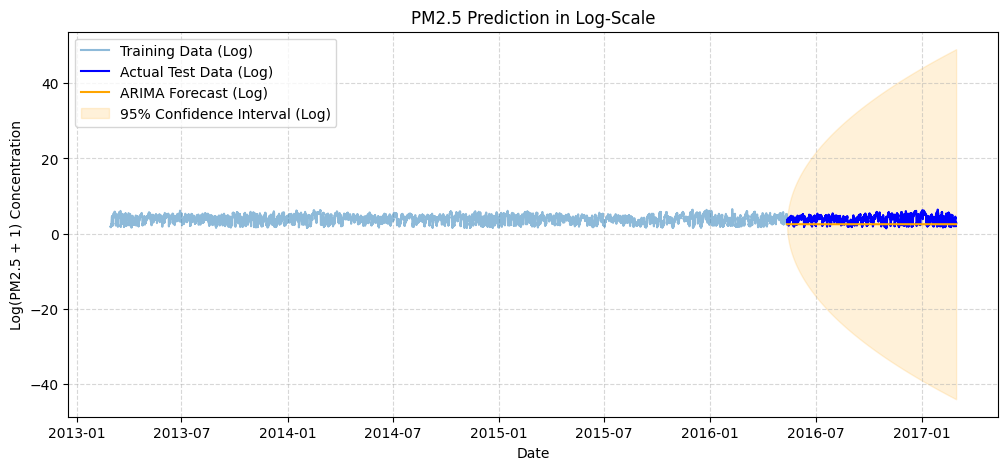

In [63]:

# Train data, test data, forecast, and intervals are ALL kept in log-scale
train_log = np.log1p(train)
test_log = np.log1p(test)

# Plotting the log-scale values directly
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train_log, label="Training Data (Log)", alpha=0.5)
plt.plot(test_log, color="blue", label="Actual Test Data (Log)")
plt.plot(y_pred_log, color="orange", label="ARIMA Forecast (Log)")

plt.fill_between(
    conf_int_log.index,
    conf_int_log.iloc[:, 0],
    conf_int_log.iloc[:, 1],
    color="orange",
    alpha=0.15,
    label="95% Confidence Interval (Log)",
)

plt.title("PM2.5 Prediction in Log-Scale")
plt.xlabel("Date")
plt.ylabel("Log(PM2.5 + 1) Concentration")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Plotting the data in log scale improved the visualization by preventing extreme values from distorting the graph. The training and testing data are clearly visible, and the confidence intervals are easier to interpret.

However, the lower confidence bound still falls into negative log values as the forecast horizon increases. This shows that although the log transformation reduces forecast uncertainty, the ARIMA model still does not fully account for the fact that PM2.5 values cannot be negative, especially in long-term forecasts.

In [64]:


# Transform your target variables to log-scale 
train_log = np.log1p(train)
test_log = np.log1p(test)

print("Fitting baseline model on training data...")
# Fit the initial model on training data 
arima_model = ARIMA(train_log, order=(1, 1, 1))
arima_fit = arima_model.fit()

print("Executing fast rolling updates across the test set...")
# Use statsmodels append() to update the baseline hour-by-hour instantly
# This simulates the rolling forecast without running a slow python loop
rolling_results = arima_fit.append(test_log, refit=False)

# Extract the 1-step-ahead rolling predictions. lag the filtered predictions by 1 step to align with the true test targets
y_pred_log = rolling_results.predict(
    start=test_log.index[0], end=test_log.index[-1]
)

# Inverse transform predictions back to original PM2.5 scale 
fc_final = np.expm1(y_pred_log)


# Define and run the evaluation 
def evaluate_log_model(y_true, y_pred, fitted_obj, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Use the final updated model object for AIC/BIC
    aic = fitted_obj.aic
    bic = fitted_obj.bic

    print(f"\n{model_name} (Log-Transformed & Rolling Update)")
    print("-" * 45)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"AIC  : {aic:.4f}")
    print(f"BIC  : {bic:.4f}")


evaluate_log_model(test, fc_final, rolling_results, "Rolling ARIMA")


Fitting baseline model on training data...
Executing fast rolling updates across the test set...

Rolling ARIMA (Log-Transformed & Rolling Update)
---------------------------------------------
MAE  : 5.3037
RMSE : 9.9378
R2   : 0.9838
AIC  : -28339.3904
BIC  : -28313.9956


Switching to a log-transformed rolling ARIMA model greatly improved performance. The errors (MAE and RMSE) dropped sharply, showing more accurate predictions, and the R² value increased to 0.9838, meaning the model explains almost all the variation in PM2.5 levels. Even the AIC and BIC scores improved significantly, confirming a better statistical fit.

#### residual diagnostic plot 

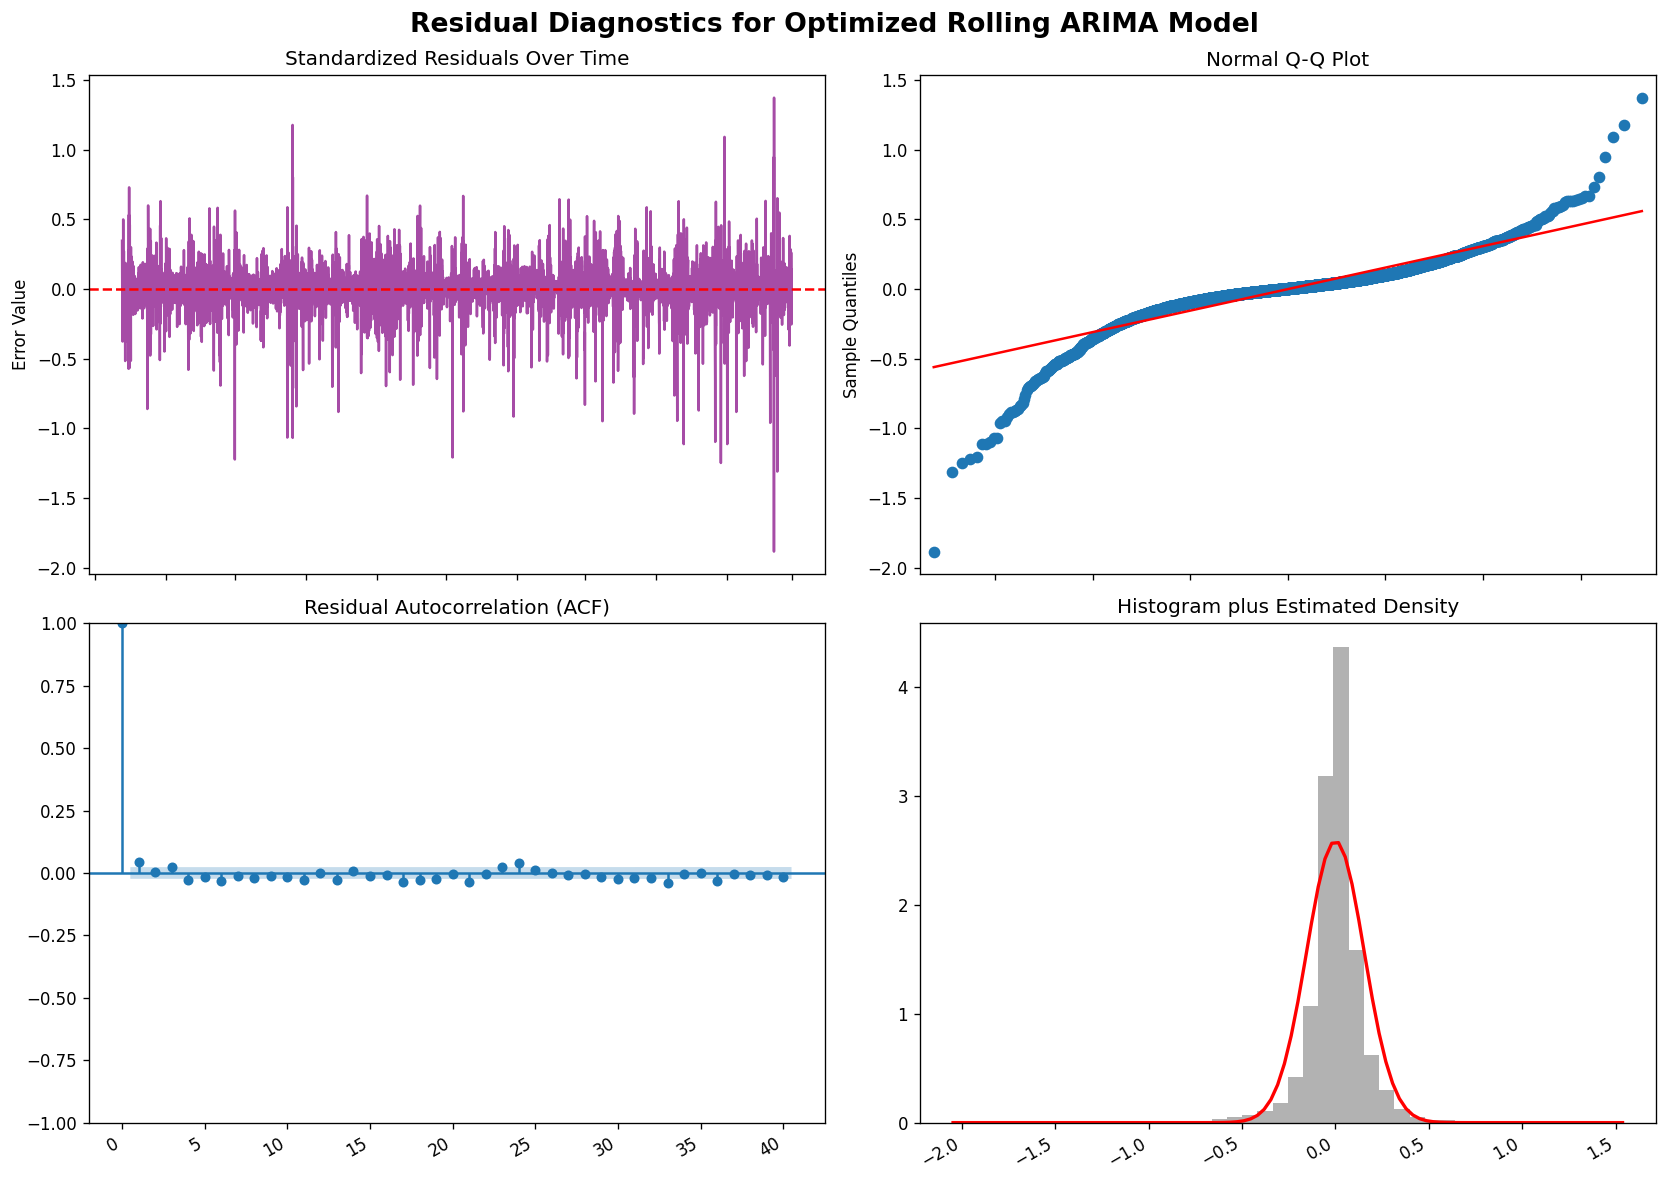

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf

# Clean drop of any potential NaNs in residuals to ensure plotting works
clean_res = (test_log - y_pred_log).dropna()

# Generate the 2x2 grid layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)

# Panel 1: Residuals over Time
axes[0, 0].plot(clean_res.index, clean_res.values, color="purple", alpha=0.7)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Standardized Residuals Over Time")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Error Value")

# Panel 2: Normal Q-Q Plot (Fixed import function call)
qqplot(clean_res, line="s", ax=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q Plot")

# Panel 3: ACF Plot of Residuals (Fixed import function call)
plot_acf(clean_res, lags=40, ax=axes[1, 0])
axes[1, 0].set_title("Residual Autocorrelation (ACF)")

# Panel 4: Distribution Histogram vs Normal Curve
axes[1, 1].hist(clean_res, bins=40, density=True, alpha=0.6, color="gray")
xmin, xmax = axes[1, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, clean_res.mean(), clean_res.std())
axes[1, 1].plot(x, p, "r-", linewidth=2)
axes[1, 1].set_title("Histogram plus Estimated Density")

# Format and adjust layout
plt.suptitle(
    "Residual Diagnostics for Optimized Rolling ARIMA Model",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


The residual diagnostics show that the optimized log-ARIMA model is statistically sound. The residuals are evenly spread around zero, meaning the variance is stable after transformation. The ACF plot shows no significant autocorrelation, confirming that the model has captured the time dependencies well. Although the distribution shows slight heavy tails from extreme pollution events, the errors are still centered and mostly symmetric. Overall, the residuals behave like white noise, indicating a well-fitted and reliable model.